> 📝 **Planning note (author use -- remove before publishing)**
>
> **Intended contents:** simple offset correction, linear pressure drift, conductivity/salinity drift-factor correction.
>
> **To do:**
> - **Write the "where do these numbers come from" section** -- currently a parenthetical heading acting as a placeholder. Reference CTD casts, bottle samples, post-recovery calibration.
> - The AT200 SBE37 was last calibrated 13-Feb-2020 and recovered Oct 2022 -- if NPI has a post-recovery calibration, that is a real number to use here instead of the made-up ones.
> - Finish the trailing "Now lets " sentence.
> - Nothing in this notebook is saved -- state that explicitly so readers do not expect a file.

<img src="../../data/images/hiaoos_learning_moored.png" width="300" align="right">

# Postprocessing and QC (Part 2): Drift and offset corrections

> Note: In this notebook, we show **examples** of correction functions. **We won't actually change the files** that we bring into subsequent notebooks. 
>
>

Continuing from the previous notebook (chopping and removing outliers), this notebook covers correcting for sensor drift and offsets:
- Simple case (pressure drift)
- Slightly more complex case (conductivity/salinity drift)

*Notebook 5 of 10 in the series*  
[← 4. Post-processing & QC I](./04_post_proc_qc_deck_time_outliers.ipynb) · [6. Slicing, averaging, interpolating →](./06_slicing_averaging_interpolating_correlating.ipynb)

In [1]:
from kval.data import moored, edit
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
ds = moored.load_nc('../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_edited.nc')

# Convert TIME from the raw number stored in the file to datetimes, so the
# plots below get proper date axes. (See notebook 6 for what this does.)
ds = moored.time_as_datetime(ds)

___

## Adjust for a known offset or drift in measured values

***Instrument sensors can drift over time.*** Typically, temperature sensors are quite stable, but pressure sensors and especially conductivity sensors more often experience drift during long deployments. In such cases, it may be necessary to compensate for the drift. 

How to do this compensation is somewhat subjective and often depends on whether other, independent measurements are available to calibrate the instrument - and on your expertise on the study site and sampling configuration.     

>**Note** It is good practice to make any corrections you think will improve the data -  while **indicating clearly in the metadata** very explicitly which corrections you have applied. This way, a user of the data is aware of what you have done and can make their own judgements - and reprocess differently from raw data if they choose. 


In many cases, we have laboratory calibrations of the instrument available both before and after deployment. Often, however, drift in conductivity is due not to the instrument electronics, but external factors like buildup of biological matter within the conductivity cell.

### Where do these correction values come from?

- Comparison with a shipboard CTD cast at deployment and/or recovery.
- Bottle samples analysed for salinity.
- Post-recovery calibration of the instrument.
- What to do when you have none of these (document the problem rather than inventing a correction).

> ✏️ Placeholder -- prose needed. This is the section that makes the rest of the notebook honest: the corrections below use made-up numbers.

(Note here too: we won't actually apply these to the dataset. When working, you may want to save the dataset to a new file, `ctd_data_after_drift_corrections.nc` or similar.)

> **A note on signs.** Throughout this notebook, a stated offset is always **measured minus true** -- i.e. a *positive* offset means the instrument reads too high. This matches the convention used by `edit.cndc_offset_from_psal_offset` further down. The *correction* is therefore the negative of the offset.

### A simple case: applying a simple offset 

Let's say that we know our temperature sensor consistently measured 0.8°C warmer than the actual temperature. Following the sign convention above, that is an offset of $+$0.8°C.

The correction is the negative of that, so we apply $-$0.8°C to the `TEMP` time series:

In [3]:
temp_offset = 0.8              # Measured minus true [°C]
ds_offset_t = moored.offset(ds, 'TEMP', -temp_offset)

This subtracts 0.8 from all data in `TEMP`. If we look at the `TEMP` variable, a note should have been appended to its metadata.

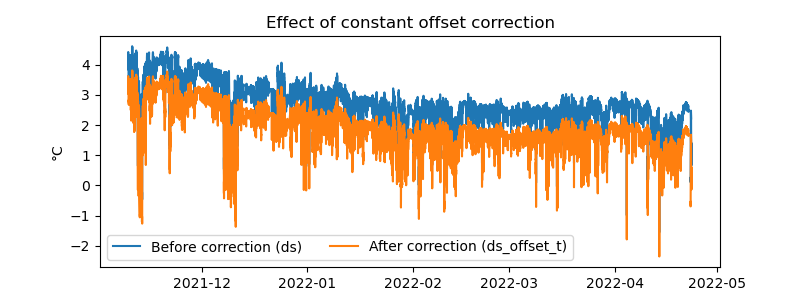

In [4]:
fig, ax = plt.subplots(figsize = (8, 3))
ax.set_title('Effect of constant offset correction')
ax.plot(ds.TIME, ds.TEMP, label = 'Before correction (ds)')
ax.plot(ds_offset_t.TIME, ds_offset_t.TEMP, label = 'After correction (ds_offset_t)')
ax.legend(ncol = 2)
ax.set_ylabel('°C');


### Adjusting for a linear pressure drift

Let's continue with pressure as an example. Assume that we know a sensor was measuring correctly on deployment, but there is a known difference `Δp` between instrument and true pressure on recovery (again: measured minus true). For example, this could be because:
- We have compared instrument pressure around recovery with independent measurements from a different, well-calibrated instrument, or:
- We observe a drift in pressure while we know that the depth was constant.
- We deliberately use an exaggerated value, `Δp`=21 dbar, so the correction is clearly visible in this example

The following adjusts the pressure to compensate, applying a correction that ramps linearly from 0 on deployment to $-$`Δp` on recovery.

In [6]:
deltaP = 21                  # Measured minus true on recovery [dbar]
ds_linear_drift_p = moored.linear_drift_offset(ds, 'PRES', end_val=-deltaP)

The same can be done for any other variable besides `PRES`. 

> ✏️ **Review note** — this was `deltaP = 21` dbar, which is far too large to be a plausible pressure drift on a 100 m mooring -- I've dropped it to 0.5 dbar. If you had 21 in there to make the effect visible on the plot, say so explicitly in the text instead, e.g. "deliberately exaggerated so the correction is visible".

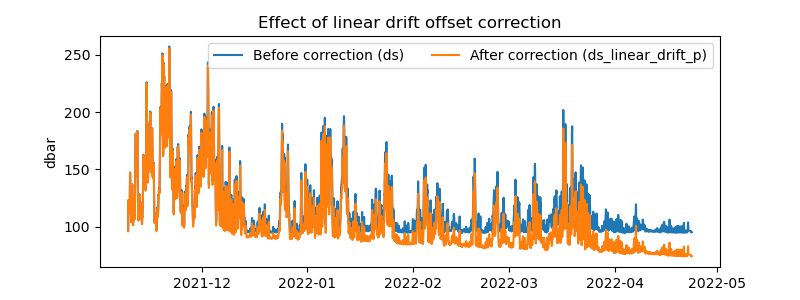

In [7]:
fig, ax = plt.subplots(figsize = (8, 3))
ax.set_title('Effect of linear drift offset correction')
ax.plot(ds.TIME, ds.PRES, label = 'Before correction (ds)')
ax.plot(ds_linear_drift_p.TIME, ds_linear_drift_p.PRES, label = 'After correction (ds_linear_drift_p)')
ax.legend(ncol = 2)
ax.set_ylabel('dbar');


### Compensating for known salinity drift

Salinity is calculated from temperature, pressure and conductivity. If we have drift in salinity, this is typically due to a drift in conductivity.

In some cases, we may deem it sufficient to apply a fixed offset of offset drift like we did for pressure above. However,

- Since it is the conductivity that drifts, we should ideally make corrections to conductivity and then recalculate salinity.
- Conductivity drift corrections should typically be applied as a *factor*, not an offset. I.e. instead of *adding* an evolving offset, we should apply a linearly evolving factor.

For example, let's say that we know initial conductivity (measurements on deployment) was correct, but we observe an offset in salinity `ΔS` on recovery. Ideally, we should then:

1. Find the conductivity offset `ΔC` corresponding to the salinity offset `ΔS` at the temperature, salinity and pressure `ΔS` was measured.
2. Find the *factor* `αC` that we need to multiply the recovery conductivity by in order to correct it to true conductivity. That factor is then ramped linearly from 1 on deployment to `αC` on recovery.

#### Find the conductivity offset

Let's say we have made independent measurements and found that true salinity was 0.92 higher than measured at the end of the record:

> *Note* 0.92 would be  *large* deviation; we use a large number in order to make changes easily visible in this examples.

In [58]:
dS_end = -0.92 # (Made-up) salinity offset. 
S_end, P_end, T_end = ds.PSAL.isel(TIME=-1), ds.PRES.isel(TIME=-1), ds.TEMP.isel(TIME=-1)

Let's find the conductivity correction needed to align measured values with observed ones:

In [62]:
C_offset, C_factor = edit.cndc_offset_from_psal_offset(dS=dS_end, S=S_end, T=T_end, P=P_end)

`C_offset` is the amount we think `CNDC` deviates from the true conductivity at this point. `C_factor`, equal to the fraction of true CNDC over measured CNDC, is the factor we'd have to apply to measured CNDC to correct for this deviation.  

In [63]:
print(f'C offset is {C_offset:.4f} mS/cm - corresponding to a factor of {C_factor:.4f}')

C offset is -0.7177 mS/cm - corresponding to a factor of 1.0239


#### Apply correction to `CNDC`

We now apply a multiplicative correction to out `CNDC`, starting at 1 at the start of the record and linearly increasing to 1.0242 at the end of the record:

<xarray.DataArray 'PSAL' ()> Size: 8B
array(1.02389773)
Coordinates:
    TIME       datetime64[ns] 8B 2022-04-23T13:58:26.529080320
    LATITUDE   float32 4B 81.55
    LONGITUDE  float32 4B 30.88

In [66]:
ds_linear_drift_CNDC_factor = moored.linear_drift_factor(ds, 'CNDC', C_factor.values)

#### Recompute `PSAL` from corrected `CNDC`

Now, we recombute out salinity `PSAL` based on the updated `CNDC`:

In [67]:
ds.TEMP.isel(TIME=-1)

<xarray.DataArray 'TEMP' ()> Size: 8B
array(1.328735)
Coordinates:
    TIME       datetime64[ns] 8B 2022-04-23T13:58:26.529080320
    LATITUDE   float32 4B ...
    LONGITUDE  float32 4B ...
Attributes:
    units:                    degC
    sensor_calibration_date:  2017-11-06

In [68]:
ds_linear_drift_CNDC_factor = moored.calculate_PSAL(ds_linear_drift_CNDC_factor)

#### Look at the effects of the correction on `CNDC`

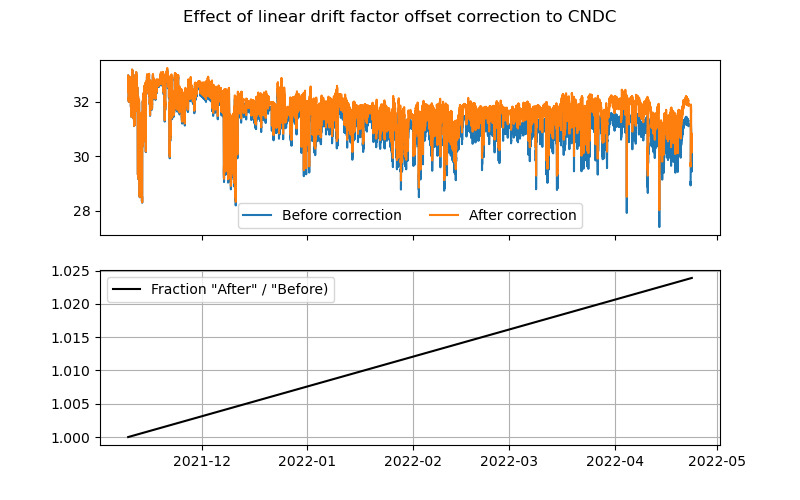

In [81]:
fig, ax = plt.subplots(2, 1, sharex = True, figsize = (8, 5))
fig.suptitle('Effect of linear drift factor offset correction to CNDC')

# Plot both salinity time series
ax[0].plot(ds.TIME, ds.CNDC, label = 'Before correction')
ax[0].plot(ds_linear_drift_CNDC_factor.TIME, ds_linear_drift_CNDC_factor.CNDC, label = 'After correction')
ax[0].legend(ncol = 2)

# Plot the DIFFERENMCE between the two salinity time series

ax[1].plot(ds.TIME, ds_linear_drift_CNDC_factor.CNDC/ds.CNDC, 'k', label = 'Fraction "After" / "Before)')
ax[1].legend(ncol =1)
ax[1].grid()

If we zoom in here, we can see that *Before correction* and *After correction* are identical at the start ofg the record, but grow increasingly different with time.

#### Look at the effects of the correction on `PSAL`

We now look at the effect this correction has had on PSAL. We should se a drift from no difference to a difference of `dS_end`=

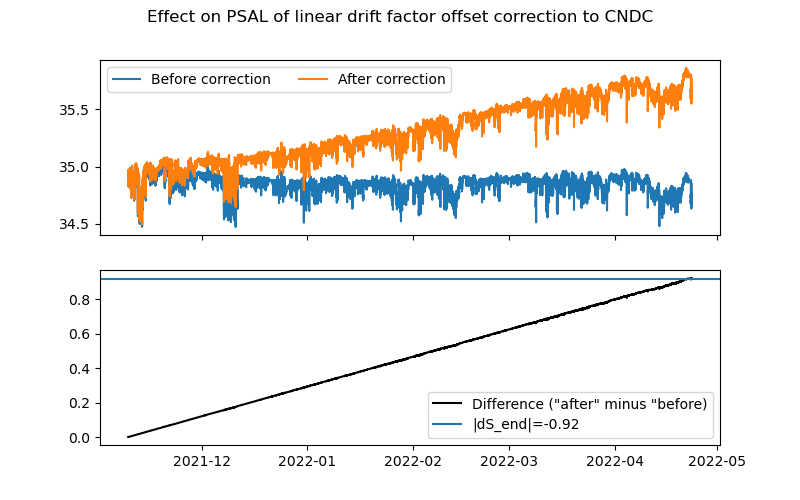

In [83]:
fig, ax = plt.subplots(2, 1, sharex = True, figsize = (8, 5))
fig.suptitle('Effect on PSAL of linear drift factor offset correction to CNDC')

# Plot both salinity time series
ax[0].plot(ds.TIME, ds.PSAL, label = 'Before correction')
ax[0].plot(ds_linear_drift_CNDC_factor.TIME, ds_linear_drift_CNDC_factor.PSAL, label = 'After correction')
ax[0].legend(ncol = 2)

# Plot the DIFFERENMCE between the two salinity time series

ax[1].plot(ds.TIME, ds_linear_drift_CNDC_factor.PSAL - ds.PSAL, 'k', label = 'Difference ("after" minus "before)')
ax[1].axhline(-dS_end, label = f'|dS_end|={dS_end}')
ax[1].legend(ncol =1)


___

**Next:** [6. Slicing, averaging, interpolating →](./06_slicing_averaging_interpolating_correlating.ipynb)